# 01 - Carga y revisión inicial de la base de ventas

Este notebook tiene como objetivo realizar una primera revisión estructural de la base `Ventas_1.csv`, enviada para el análisis exploratorio de datos del proyecto de ventas de Olímpica.

En esta sección se revisan los siguientes aspectos:

- Carga del archivo original.
- Dimensiones generales de la base.
- Tipos de variables.
- Primeras observaciones de las columnas.
- Valores nulos.
- Registros duplicados.
- Cardinalidad de variables principales.
- Rango de fechas disponible.
- Cantidad de PDV, productos, categorías y facturas.
- Primeras métricas generales de venta, cantidad y descuento.

Este notebook no realiza la limpieza definitiva de la base. Su propósito es entender la estructura inicial del archivo y detectar posibles problemas que serán tratados en el siguiente notebook.

In [1]:
# ===============================
# Imports principales
# ===============================

from pathlib import Path
import sys
import os

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:,.2f}".format)

sns.set_theme(style="whitegrid", context="notebook")

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


In [2]:
# ===============================
# Rutas del proyecto
# ===============================

PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
INTERIM_DIR = DATA_DIR / "interim"
PROCESSED_DIR = DATA_DIR / "processed"

REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"
TABLES_DIR = REPORTS_DIR / "tables"

RAW_FILE = RAW_DIR / "Ventas_1.csv"

print("Raíz del proyecto:")
print(PROJECT_ROOT)

print("\nArchivo original:")
print(RAW_FILE)

print("\n¿Existe el archivo?")
print(RAW_FILE.exists())

Raíz del proyecto:
c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica

Archivo original:
c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\data\raw\Ventas_1.csv

¿Existe el archivo?
True


In [3]:
# ===============================
# Carga de la base original
# ===============================

df = pd.read_csv(
    RAW_FILE,
    encoding="utf-8-sig",
    dtype={
        "CATEG": str,
        "PLU_SAP": str,
        "FACTURA": str,
        "PDV": str,
        "OFERTA_ID": str,
        "GRUCOM": str,
        "Estrato": str
    },
    low_memory=False
)

print("Base cargada correctamente.")
print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]:,}")

Base cargada correctamente.
Filas: 409,760
Columnas: 12


In [4]:
# ===============================
# Primeras filas
# ===============================

df.head()

,NroReg,FECHA,PDV,Estrato,OFERTA_ID,FACTURA,CATEG,PLU_SAP,CANT,VENTA,DESCUENTO,GRUCOM
0,4,44927,980,4,0,1,04010,1280454,3,298,"0,00",10
1,12,44927,1255,4,0,2,04010,1328730,1,115,"0,00",10
2,24,44927,1255,4,0,3,04010,1036266,3,448,"0,00",10
3,36,44927,1311,6,0,4,08061,1265857,1,82,"0,00",11
4,37,44927,980,4,0,5,04010,1328946,4,519,"0,00",10


In [5]:
# ===============================
# Últimas filas
# ===============================

df.tail()

,NroReg,FECHA,PDV,Estrato,OFERTA_ID,FACTURA,CATEG,PLU_SAP,CANT,VENTA,DESCUENTO,GRUCOM
409755,8591485,45657,980,4,0,233742,04010,1036252,3,594,"0,00",10
409756,8591507,45657,1255,4,225420,169556,04010,1026996,1,912,"34,00",10
409757,8591516,45657,1255,4,0,222672,04010,1313279,1,198,"0,00",10
409758,8591520,45657,980,4,227072,233879,04010,1377188,1,67,"101,00",10
409759,8591532,45657,1255,4,0,209343,08029,1194777,"0,04",23,"0,00",11


In [6]:
# ===============================
# Muestra aleatoria
# ===============================

df.sample(10, random_state=42)

,NroReg,FECHA,PDV,Estrato,OFERTA_ID,FACTURA,CATEG,PLU_SAP,CANT,VENTA,DESCUENTO,GRUCOM
105080,2278633,45100,1311,6,176424,70166,04010,1027276,1,468,"200,00",10
357547,7518308,45548,1311,6,217077,215180,04010,1023807,1,990,"660,00",10
318578,6663996,45463,1311,6,0,200776,04010,1021969,1,91,"0,00",10
303618,6359494,45434,1255,4,204229,170958,08042,1015664,1,483,"161,00",11
408731,8579712,45657,1311,6,0,233722,04010,1313279,1,198,"0,00",10
400372,8442436,45643,1311,6,0,230925,08042,1014797,1,744,"0,00",11
205668,4404517,45266,980,4,0,136269,04010,1336391,2,140,"0,00",10
79962,1736947,45058,1311,6,0,53448,04010,1036252,1,169,"0,00",10
171604,3705358,45210,980,4,0,114476,08061,1008766,1,149,"0,00",11
379439,8004400,45598,1311,6,0,223193,04010,1371769,1,202,"0,00",10


In [7]:
# ===============================
# Columnas de la base
# ===============================

columnas = pd.DataFrame({
    "columna": df.columns,
    "tipo_dato": df.dtypes.astype(str).values,
    "nulos": df.isna().sum().values,
    "nulos_pct": (df.isna().mean().values * 100).round(4),
    "unicos": df.nunique(dropna=False).values
})

columnas

,columna,tipo_dato,nulos,nulos_pct,unicos
0,NroReg,int64,0,0.00,409760
1,FECHA,int64,0,0.00,731
2,PDV,str,0,0.00,3
3,Estrato,str,0,0.00,2
4,OFERTA_ID,str,0,0.00,3123
5,FACTURA,str,0,0.00,233889
6,CATEG,str,0,0.00,7
7,PLU_SAP,str,0,0.00,6039
8,CANT,str,180,0.04,242
9,VENTA,int64,0,0.00,4083


In [8]:
# ===============================
# Información general del DataFrame
# ===============================

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 409760 entries, 0 to 409759
Data columns (total 12 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   NroReg     409760 non-null  int64
 1   FECHA      409760 non-null  int64
 2   PDV        409760 non-null  str  
 3   Estrato    409760 non-null  str  
 4   OFERTA_ID  409760 non-null  str  
 5   FACTURA    409760 non-null  str  
 6   CATEG      409760 non-null  str  
 7   PLU_SAP    409760 non-null  str  
 8   CANT       409580 non-null  str  
 9   VENTA      409760 non-null  int64
 10  DESCUENTO  409760 non-null  str  
 11  GRUCOM     409760 non-null  str  
dtypes: int64(3), str(9)
memory usage: 50.3 MB


In [9]:
# ===============================
# Dimensiones generales
# ===============================

n_filas, n_columnas = df.shape

print(f"Número de filas: {n_filas:,}")
print(f"Número de columnas: {n_columnas:,}")
print(f"Número total de celdas: {n_filas * n_columnas:,}")

Número de filas: 409,760
Número de columnas: 12
Número total de celdas: 4,917,120


## Diccionario inicial de variables

A partir de la estructura observada, la base contiene las siguientes variables:

| Variable | Descripción inicial |
|---|---|
| `NroReg` | Identificador de registro o línea de venta |
| `FECHA` | Fecha de la transacción en formato serial de Excel |
| `PDV` | Punto de venta o tienda |
| `Estrato` | Estrato asociado al punto de venta |
| `OFERTA_ID` | Identificador de oferta o promoción |
| `FACTURA` | Número de factura |
| `CATEG` | Categoría del producto |
| `PLU_SAP` | Código del producto o SKU |
| `CANT` | Cantidad vendida |
| `VENTA` | Valor bruto de la venta |
| `DESCUENTO` | Valor del descuento aplicado |
| `GRUCOM` | Grupo comercial |

Una observación importante es que la base parece estar a nivel de línea de venta, no a nivel de factura completa. Es decir, una misma factura puede aparecer en varias filas si contiene varios productos.

In [10]:
# ===============================
# Valores nulos
# ===============================

nulos = (
    df.isna()
    .sum()
    .reset_index()
    .rename(columns={"index": "columna", 0: "nulos"})
)

nulos["nulos_pct"] = (nulos["nulos"] / len(df) * 100).round(4)
nulos = nulos.sort_values("nulos", ascending=False)

nulos

,columna,nulos,nulos_pct
8,CANT,180,0.04
0,NroReg,0,0.00
2,PDV,0,0.00
1,FECHA,0,0.00
3,Estrato,0,0.00
4,OFERTA_ID,0,0.00
6,CATEG,0,0.00
5,FACTURA,0,0.00
7,PLU_SAP,0,0.00
9,VENTA,0,0.00


In [11]:
# ===============================
# Columnas con valores nulos
# ===============================

nulos[nulos["nulos"] > 0]

,columna,nulos,nulos_pct
8,CANT,180,0.04


In [12]:
# ===============================
# Duplicados completos
# ===============================

duplicados_completos = df.duplicated().sum()

print(f"Filas duplicadas completas: {duplicados_completos:,}")
print(f"Porcentaje de duplicados completos: {duplicados_completos / len(df) * 100:.4f}%")

Filas duplicadas completas: 0
Porcentaje de duplicados completos: 0.0000%


In [13]:
# ===============================
# Revisión de duplicados en NroReg
# ===============================

if "NroReg" in df.columns:
    duplicados_nroreg = df["NroReg"].duplicated().sum()
    print(f"NroReg duplicados: {duplicados_nroreg:,}")
    print(f"NroReg únicos: {df['NroReg'].nunique():,}")
else:
    print("La columna NroReg no existe en la base.")

NroReg duplicados: 0
NroReg únicos: 409,760


In [14]:
# ===============================
# Cardinalidad de variables principales
# ===============================

variables_clave = ["FECHA", "PDV", "Estrato", "OFERTA_ID", "FACTURA", "CATEG", "PLU_SAP", "GRUCOM"]

cardinalidad = []

for col in variables_clave:
    if col in df.columns:
        cardinalidad.append({
            "variable": col,
            "valores_unicos": df[col].nunique(dropna=False),
            "porcentaje_sobre_filas": df[col].nunique(dropna=False) / len(df) * 100
        })

cardinalidad = pd.DataFrame(cardinalidad)
cardinalidad

,variable,valores_unicos,porcentaje_sobre_filas
0,FECHA,731,0.18
1,PDV,3,0.00
2,Estrato,2,0.00
3,OFERTA_ID,3123,0.76
4,FACTURA,233889,57.08
5,CATEG,7,0.00
6,PLU_SAP,6039,1.47
7,GRUCOM,2,0.00


In [15]:
# ===============================
# Valores únicos en variables categóricas pequeñas
# ===============================

for col in ["PDV", "Estrato", "CATEG", "GRUCOM"]:
    if col in df.columns:
        print("=" * 60)
        print(f"Variable: {col}")
        print(df[col].value_counts(dropna=False).sort_index())

Variable: PDV
PDV
1255    132627
1311    201432
980      75701
Name: count, dtype: int64
Variable: Estrato
Estrato
4    208328
6    201432
Name: count, dtype: int64
Variable: CATEG
CATEG
04010    158659
04019       397
08029    132505
08042     52788
08061     53538
08062     10997
08067       876
Name: count, dtype: int64
Variable: GRUCOM
GRUCOM
10    159056
11    250704
Name: count, dtype: int64


In [16]:
# ===============================
# Conversión preliminar de fecha
# ===============================

df["FECHA_REAL_PRELIM"] = pd.to_datetime(
    df["FECHA"],
    unit="D",
    origin="1899-12-30",
    errors="coerce"
)

print("Fecha mínima:", df["FECHA_REAL_PRELIM"].min())
print("Fecha máxima:", df["FECHA_REAL_PRELIM"].max())
print("Días únicos:", df["FECHA_REAL_PRELIM"].nunique())

Fecha mínima: 2023-01-01 00:00:00
Fecha máxima: 2024-12-31 00:00:00
Días únicos: 731


In [17]:
# ===============================
# Revisión de fechas faltantes
# ===============================

fecha_min = df["FECHA_REAL_PRELIM"].min()
fecha_max = df["FECHA_REAL_PRELIM"].max()

rango_fechas = pd.date_range(start=fecha_min, end=fecha_max, freq="D")
fechas_observadas = pd.Series(df["FECHA_REAL_PRELIM"].dropna().unique())

fechas_faltantes = sorted(set(rango_fechas) - set(fechas_observadas))

print(f"Fecha inicial: {fecha_min.date()}")
print(f"Fecha final: {fecha_max.date()}")
print(f"Días esperados en el rango: {len(rango_fechas):,}")
print(f"Días observados: {df['FECHA_REAL_PRELIM'].nunique():,}")
print(f"Días faltantes: {len(fechas_faltantes):,}")

if len(fechas_faltantes) > 0:
    print("\nPrimeras fechas faltantes:")
    print(fechas_faltantes[:10])
else:
    print("\nNo se encontraron fechas faltantes en el rango.")

Fecha inicial: 2023-01-01
Fecha final: 2024-12-31
Días esperados en el rango: 731
Días observados: 731
Días faltantes: 0

No se encontraron fechas faltantes en el rango.


In [18]:
# ===============================
# Resumen preliminar por año
# ===============================

df["ANIO_PRELIM"] = df["FECHA_REAL_PRELIM"].dt.year

resumen_anio = (
    df.groupby("ANIO_PRELIM")
    .agg(
        filas=("NroReg", "count"),
        dias=("FECHA_REAL_PRELIM", "nunique"),
        pdv=("PDV", "nunique"),
        productos=("PLU_SAP", "nunique"),
        categorias=("CATEG", "nunique"),
        facturas=("FACTURA", "nunique")
    )
    .reset_index()
)

resumen_anio

,ANIO_PRELIM,filas,dias,pdv,productos,categorias,facturas
0,2023,228150,365,3,5410,7,150248
1,2024,181610,366,3,4845,7,85270


In [19]:
# ===============================
# Conversión preliminar de columnas numéricas
# ===============================

def convertir_decimal_preliminar(serie):
    """
    Convierte una serie con posibles comas decimales a formato numérico.
    """
    return pd.to_numeric(
        serie.astype(str)
        .str.replace(",", ".", regex=False)
        .str.replace('"', "", regex=False)
        .str.strip(),
        errors="coerce"
    )

df["CANT_PRELIM"] = convertir_decimal_preliminar(df["CANT"])
df["VENTA_PRELIM"] = pd.to_numeric(df["VENTA"], errors="coerce")
df["DESCUENTO_PRELIM"] = convertir_decimal_preliminar(df["DESCUENTO"])

df["VENTA_NETA_PRELIM"] = df["VENTA_PRELIM"] - df["DESCUENTO_PRELIM"]

print("Conversión preliminar finalizada.")

Conversión preliminar finalizada.


In [20]:
# ===============================
# Estadísticos descriptivos preliminares
# ===============================

cols_numericas_prelim = [
    "CANT_PRELIM",
    "VENTA_PRELIM",
    "DESCUENTO_PRELIM",
    "VENTA_NETA_PRELIM"
]

df[cols_numericas_prelim].describe().T

,count,mean,std,min,25%,50%,75%,max
CANT_PRELIM,"409,580.00",1.21,3.51,-24.00,1.00,1.00,1.00,800.00
VENTA_PRELIM,"409,760.00",340.35,807.68,"-32,896.00",83.00,178.00,398.00,"195,457.00"
DESCUENTO_PRELIM,"409,760.00",39.71,269.24,-862.00,0.00,0.00,8.00,"80,080.00"
VENTA_NETA_PRELIM,"409,760.00",300.65,754.94,"-43,460.00",75.00,164.00,342.00,"195,457.00"


In [21]:
# ===============================
# Casos especiales preliminares
# ===============================

casos_especiales = {
    "Filas totales": len(df),
    "CANT nula": df["CANT_PRELIM"].isna().sum(),
    "CANT igual a 0": (df["CANT_PRELIM"] == 0).sum(),
    "CANT negativa": (df["CANT_PRELIM"] < 0).sum(),
    "VENTA nula": df["VENTA_PRELIM"].isna().sum(),
    "VENTA igual a 0": (df["VENTA_PRELIM"] == 0).sum(),
    "VENTA negativa": (df["VENTA_PRELIM"] < 0).sum(),
    "DESCUENTO nulo": df["DESCUENTO_PRELIM"].isna().sum(),
    "DESCUENTO igual a 0": (df["DESCUENTO_PRELIM"] == 0).sum(),
    "DESCUENTO negativo": (df["DESCUENTO_PRELIM"] < 0).sum(),
    "DESCUENTO mayor que VENTA": (df["DESCUENTO_PRELIM"] > df["VENTA_PRELIM"]).sum(),
    "VENTA_NETA negativa": (df["VENTA_NETA_PRELIM"] < 0).sum(),
    "VENTA_NETA igual a 0": (df["VENTA_NETA_PRELIM"] == 0).sum()
}

casos_especiales_df = pd.DataFrame(
    casos_especiales.items(),
    columns=["caso", "cantidad"]
)

casos_especiales_df["porcentaje"] = (
    casos_especiales_df["cantidad"] / len(df) * 100
).round(4)

casos_especiales_df

,caso,cantidad,porcentaje
0,Filas totales,409760,100.00
1,CANT nula,180,0.04
2,CANT igual a 0,2322,0.57
3,CANT negativa,133,0.03
4,VENTA nula,0,0.00
5,VENTA igual a 0,3470,0.85
6,VENTA negativa,1763,0.43
7,DESCUENTO nulo,0,0.00
8,DESCUENTO igual a 0,300755,73.40
9,DESCUENTO negativo,12,0.00


In [22]:
# ===============================
# Métricas generales preliminares
# ===============================

venta_bruta_total = df["VENTA_PRELIM"].sum()
descuento_total = df["DESCUENTO_PRELIM"].sum()
venta_neta_total = df["VENTA_NETA_PRELIM"].sum()
unidades_totales = df["CANT_PRELIM"].sum()

resumen_general = pd.DataFrame({
    "metrica": [
        "Filas",
        "PDV únicos",
        "Productos únicos",
        "Categorías únicas",
        "Facturas únicas globales",
        "Días únicos",
        "Venta bruta total",
        "Descuento total",
        "Venta neta total",
        "Unidades totales",
        "Descuento / Venta bruta (%)"
    ],
    "valor": [
        len(df),
        df["PDV"].nunique(),
        df["PLU_SAP"].nunique(),
        df["CATEG"].nunique(),
        df["FACTURA"].nunique(),
        df["FECHA_REAL_PRELIM"].nunique(),
        venta_bruta_total,
        descuento_total,
        venta_neta_total,
        unidades_totales,
        descuento_total / venta_bruta_total * 100 if venta_bruta_total != 0 else np.nan
    ]
})

resumen_general

,metrica,valor
0,Filas,"409,760.00"
1,PDV únicos,3.00
2,Productos únicos,"6,039.00"
3,Categorías únicas,7.00
4,Facturas únicas globales,"233,889.00"
5,Días únicos,731.00
6,Venta bruta total,"139,462,498.00"
7,Descuento total,"16,270,136.00"
8,Venta neta total,"123,192,362.00"
9,Unidades totales,"494,973.23"


In [23]:
# ===============================
# Identificador preliminar de ticket
# ===============================

df["TICKET_ID_PRELIM"] = (
    df["FECHA_REAL_PRELIM"].dt.strftime("%Y-%m-%d") + "_" +
    df["PDV"].astype(str) + "_" +
    df["FACTURA"].astype(str)
)

print(f"Facturas únicas globales: {df['FACTURA'].nunique():,}")
print(f"Tickets únicos preliminares FECHA + PDV + FACTURA: {df['TICKET_ID_PRELIM'].nunique():,}")

Facturas únicas globales: 233,889
Tickets únicos preliminares FECHA + PDV + FACTURA: 276,989


In [24]:
# ===============================
# Resumen preliminar por PDV
# ===============================

resumen_pdv = (
    df.groupby(["PDV", "Estrato"])
    .agg(
        filas=("NroReg", "count"),
        dias=("FECHA_REAL_PRELIM", "nunique"),
        tickets=("TICKET_ID_PRELIM", "nunique"),
        productos=("PLU_SAP", "nunique"),
        categorias=("CATEG", "nunique"),
        venta_bruta=("VENTA_PRELIM", "sum"),
        descuento=("DESCUENTO_PRELIM", "sum"),
        venta_neta=("VENTA_NETA_PRELIM", "sum"),
        unidades=("CANT_PRELIM", "sum")
    )
    .reset_index()
)

resumen_pdv["participacion_venta_neta_pct"] = (
    resumen_pdv["venta_neta"] / resumen_pdv["venta_neta"].sum() * 100
).round(2)

resumen_pdv["ticket_promedio_neto"] = (
    resumen_pdv["venta_neta"] / resumen_pdv["tickets"]
).round(2)

resumen_pdv.sort_values("venta_neta", ascending=False)

,PDV,Estrato,filas,dias,tickets,productos,categorias,venta_bruta,descuento,venta_neta,unidades,participacion_venta_neta_pct,ticket_promedio_neto
1,1311,6,201432,731,129256,5142,7,80638414,"8,777,219.00","71,861,195.00","232,738.60",58.33,555.96
0,1255,4,132627,731,93693,3736,7,38023322,"5,281,154.00","32,742,168.00","165,580.55",26.58,349.46
2,980,4,75701,731,54040,2461,6,20800762,"2,211,763.00","18,588,999.00","96,654.08",15.09,343.99


In [25]:
# ===============================
# Resumen preliminar por categoría
# ===============================

resumen_categoria = (
    df.groupby(["GRUCOM", "CATEG"])
    .agg(
        filas=("NroReg", "count"),
        dias=("FECHA_REAL_PRELIM", "nunique"),
        tickets=("TICKET_ID_PRELIM", "nunique"),
        productos=("PLU_SAP", "nunique"),
        venta_bruta=("VENTA_PRELIM", "sum"),
        descuento=("DESCUENTO_PRELIM", "sum"),
        venta_neta=("VENTA_NETA_PRELIM", "sum"),
        unidades=("CANT_PRELIM", "sum")
    )
    .reset_index()
)

resumen_categoria["participacion_venta_neta_pct"] = (
    resumen_categoria["venta_neta"] / resumen_categoria["venta_neta"].sum() * 100
).round(2)

resumen_categoria.sort_values("venta_neta", ascending=False)

,GRUCOM,CATEG,filas,dias,tickets,productos,venta_bruta,descuento,venta_neta,unidades,participacion_venta_neta_pct
0,10,04010,158659,731,121604,1173,61096386,"7,317,028.00","53,779,358.00","244,163.00",43.65
3,11,08042,52788,731,41127,1748,29985976,"2,868,994.00","27,116,982.00","60,593.26",22.01
2,11,08029,132505,731,95594,1391,29011472,"3,044,652.00","25,966,820.00","123,061.92",21.08
4,11,08061,53538,731,42098,804,10970778,"816,908.00","10,153,870.00","54,349.08",8.24
5,11,08062,10997,723,8608,666,7667928,"2,222,411.00","5,445,517.00","10,972.18",4.42
6,11,08067,876,304,355,255,698356,143.00,"698,213.00","1,373.79",0.57
1,10,04019,397,288,392,2,31602,0.00,"31,602.00",460.00,0.03


In [26]:
# ===============================
# Top 20 productos por venta neta
# ===============================

top_productos_venta = (
    df.groupby("PLU_SAP")
    .agg(
        filas=("NroReg", "count"),
        dias=("FECHA_REAL_PRELIM", "nunique"),
        pdv=("PDV", "nunique"),
        categorias=("CATEG", "nunique"),
        tickets=("TICKET_ID_PRELIM", "nunique"),
        venta_neta=("VENTA_NETA_PRELIM", "sum"),
        unidades=("CANT_PRELIM", "sum")
    )
    .reset_index()
    .sort_values("venta_neta", ascending=False)
    .head(20)
)

top_productos_venta

,PLU_SAP,filas,dias,pdv,categorias,tickets,venta_neta,unidades
1513,1036246,7872,719,3,1,7675,"1,958,957.00","10,799.00"
1518,1036266,4699,697,3,1,4397,"1,627,878.00","14,374.00"
4657,1331944,2142,569,3,1,2117,"1,369,148.00","3,143.00"
4936,1338873,8419,701,3,1,8064,"1,311,741.00","13,508.00"
3166,1246431,842,79,3,1,627,"1,263,074.00","1,606.00"
1515,1036252,5075,708,3,1,4735,"1,225,589.00","8,419.00"
1516,1036253,2824,633,3,1,2682,"1,208,016.00","14,342.00"
4155,1313279,4665,695,3,1,4299,"1,082,770.00","6,971.00"
1324,1023807,663,345,3,1,615,"995,053.00",771.00
1556,1041245,803,410,3,1,793,"894,911.00","2,724.00"


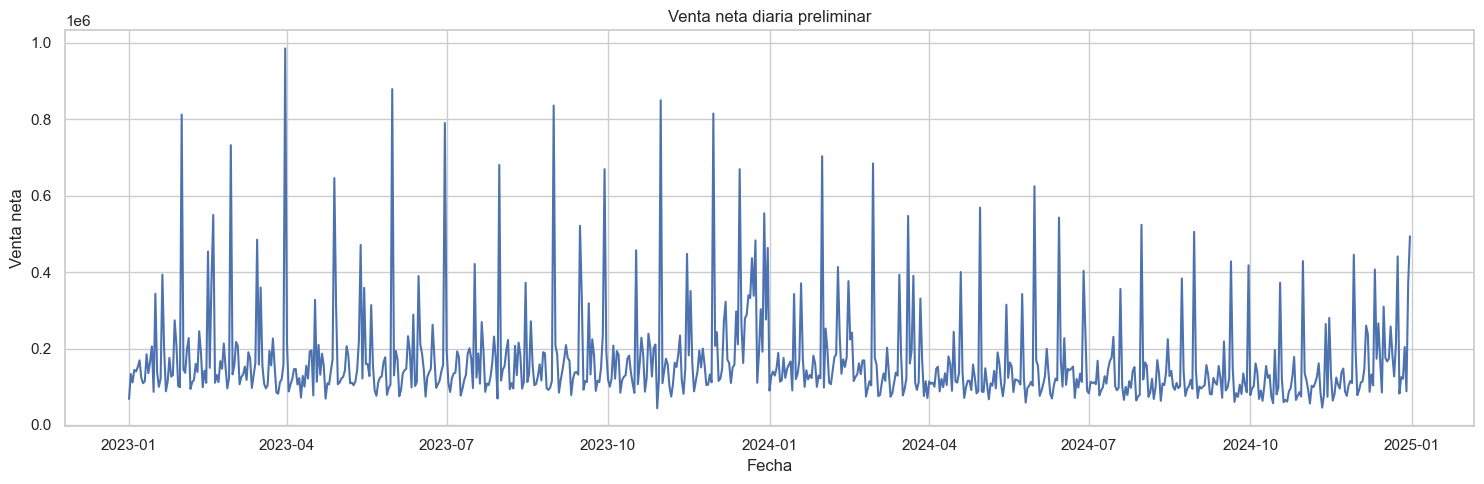

In [27]:
# ===============================
# Serie diaria preliminar de venta neta
# ===============================

ventas_diarias = (
    df.groupby("FECHA_REAL_PRELIM")
    .agg(
        venta_neta=("VENTA_NETA_PRELIM", "sum"),
        venta_bruta=("VENTA_PRELIM", "sum"),
        descuento=("DESCUENTO_PRELIM", "sum"),
        unidades=("CANT_PRELIM", "sum"),
        tickets=("TICKET_ID_PRELIM", "nunique")
    )
    .reset_index()
)

plt.figure(figsize=(15, 5))
sns.lineplot(data=ventas_diarias, x="FECHA_REAL_PRELIM", y="venta_neta")
plt.title("Venta neta diaria preliminar")
plt.xlabel("Fecha")
plt.ylabel("Venta neta")
plt.tight_layout()
plt.show()

In [28]:
# ===============================
# Exportar tablas resumen iniciales
# ===============================

output_file = TABLES_DIR / "01_revision_inicial.xlsx"

with pd.ExcelWriter(output_file, engine="openpyxl") as writer:
    columnas.to_excel(writer, sheet_name="columnas", index=False)
    nulos.to_excel(writer, sheet_name="nulos", index=False)
    cardinalidad.to_excel(writer, sheet_name="cardinalidad", index=False)
    resumen_general.to_excel(writer, sheet_name="resumen_general", index=False)
    casos_especiales_df.to_excel(writer, sheet_name="casos_especiales", index=False)
    resumen_anio.to_excel(writer, sheet_name="resumen_anio", index=False)
    resumen_pdv.to_excel(writer, sheet_name="resumen_pdv", index=False)
    resumen_categoria.to_excel(writer, sheet_name="resumen_categoria", index=False)
    top_productos_venta.to_excel(writer, sheet_name="top_productos", index=False)

print(f"Archivo exportado correctamente en: {output_file}")

Archivo exportado correctamente en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\tables\01_revision_inicial.xlsx


## Conclusiones de la revisión inicial

A partir de la carga y revisión inicial de la base, se identifican varios puntos importantes:

1. La base corresponde a información transaccional a nivel de línea de venta. Esto significa que cada fila representa un producto vendido dentro de una factura, no una factura completa.

2. La columna `FECHA` se encuentra en formato serial de Excel, por lo que debe convertirse a fecha real para cualquier análisis temporal.

3. Algunas variables que deberían ser numéricas, como `CANT` y `DESCUENTO`, requieren tratamiento especial debido al uso de coma decimal.

4. La columna `CATEG` debe manejarse como texto para conservar posibles ceros iniciales en los códigos de categoría.

5. La variable `FACTURA` no debe usarse sola como identificador único de ticket. Es más recomendable construir un identificador combinando fecha, PDV y factura.

6. Existen casos especiales que deben analizarse con más detalle, como ventas negativas, cantidades negativas, ventas en cero, descuentos negativos y descuentos mayores que la venta.

7. La variable más importante para el análisis posterior será `VENTA_NETA`, calculada como la diferencia entre `VENTA` y `DESCUENTO`.

8. La base contiene información suficiente para realizar análisis por fecha, PDV, categoría, producto, ticket y promoción.

